Logistics Regression


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the dataset

data = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Pass": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]  # 0 = Fail, 1 = Pass
})
print(data)

   study_hours  Pass
0            1     0
1            2     0
2            3     0
3            4     0
4            5     1
5            6     1
6            7     1
7            8     1
8            9     1
9           10     1


In [ ]:
#Split the data into Feature and Target
X = data[["study_hours"]]  # Features (2D DataFrame)
y = data["Pass"]

Train /Test Split(70% Training, 30% Testing)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


Train the model

In [ ]:
model = LogisticRegression(solver="liblinear", random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

Inspect model

In [ ]:
print("Intercept (β0):", model.intercept_[0])
print("Coefficient for study_hours (β1):", model.coef_[0][0])

Intercept (β0): -0.824225819423688
Coefficient for study_hours (β1): 0.35386065423963553


Make Predictions

In [ ]:
proba = model.predict_proba(X_test)[:, 1]  # Probability of Pass=1
pred_default = model.predict(X_test)       # Default threshold = 0.5
print("Probabilities:", proba.round(3))
print("Predicted labels (0/1):", pred_default)

Probabilities: [0.559 0.914 0.839]
Predicted labels (0/1): [1 1 1]


Evaluate Performance

In [ ]:
print("Accuracy:", accuracy_score(y_test, pred_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_default))
print("Classification Report:\n", classification_report(y_test, pred_default, digits=3))

Accuracy: 0.6666666666666666
Confusion Matrix:
 [[0 1]
 [0 2]]
Classification Report:
               precision    recall  f1-score   support

           0      0.000     0.000     0.000         1
           1      0.667     1.000     0.800         2

    accuracy                          0.667         3
   macro avg      0.333     0.500     0.400         3
weighted avg      0.444     0.667     0.533         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualize the result

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


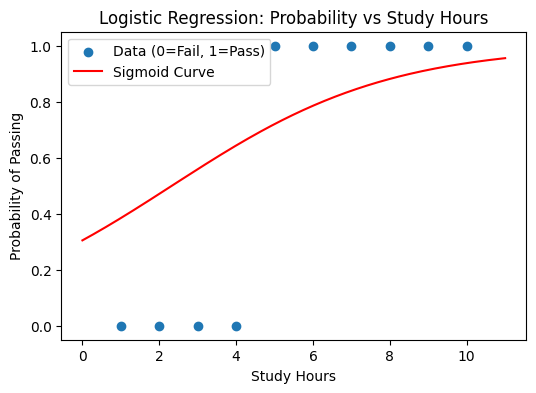

In [ ]:
hours = np.linspace(0, 11, 200).reshape(-1, 1)
proba_curve = model.predict_proba(hours)[:, 1]

plt.figure(figsize=(6, 4))
plt.scatter(X["study_hours"], y, label="Data (0=Fail, 1=Pass)")
plt.plot(hours, proba_curve, color="red", label="Sigmoid Curve")
plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression: Probability vs Study Hours")
plt.legend()
plt.show()